load data

In [2]:
import ast
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

DATA_DIR = Path("../data/raw/lthing_data")

# load reviews
records = []
with open(DATA_DIR / "reviews.txt") as f:
    for line in tqdm(f, desc="loading reviews"):
        line = line.strip()
        if not line.startswith("reviews["):
            continue
        try:
            sep = line.index(" = ")
            records.append(ast.literal_eval(line[sep + 3:]))
        except (ValueError, SyntaxError):
            continue

reviews = pd.DataFrame(records)
reviews = (
    reviews
    .drop(columns=["time"])
    .rename(columns={"work": "item", "unixtime": "time"})
    [["user", "item", "stars", "time"]]
    .dropna()
)
reviews["time"] = reviews["time"].astype("int64")

# load edges
edge_rows = []
with open(DATA_DIR / "edges.txt") as f:
    for line in f:
        parts = line.split()
        if len(parts) == 2:
            edge_rows.append({"src": parts[0], "dst": parts[1]})
edges = pd.DataFrame(edge_rows)

print(f"reviews: {len(reviews):,} rows, {reviews['user'].nunique():,} users, {reviews['item'].nunique():,} items")
print(f"edges:   {len(edges):,} rows")
reviews.head(3)

loading reviews: 1707071it [01:07, 25451.61it/s]


reviews: 1,387,125 rows, 70,618 users, 385,251 items
edges:   219,790 rows


,user,item,stars,time
0,Elizabeth.Wong98,73960,4.5,1332288000
1,rivkat,69413,3.0,1253404800
2,suz.haugland,9523995,4.0,1299888000


basic visualizations

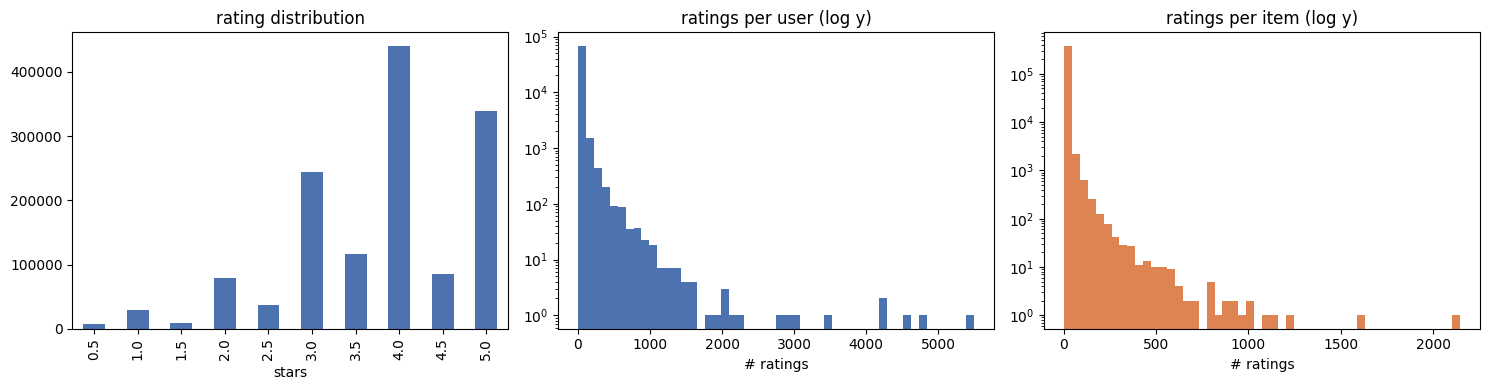

sparsity:         0.0051%
mean stars:       3.805
median user count:3
median item count:1
cold users (<=5): 62.5%
cold items (<=5): 89.1%


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# rating distribution
reviews["stars"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("rating distribution")
axes[0].set_xlabel("stars")

# ratings per user (log scale)
user_counts = reviews["user"].value_counts()
axes[1].hist(user_counts, bins=50, color="#4C72B0", log=True)
axes[1].set_title("ratings per user (log y)")
axes[1].set_xlabel("# ratings")

# ratings per item (log scale)
item_counts = reviews["item"].value_counts()
axes[2].hist(item_counts, bins=50, color="#DD8452", log=True)
axes[2].set_title("ratings per item (log y)")
axes[2].set_xlabel("# ratings")

plt.tight_layout()
plt.show()

# key numbers
sparsity = len(reviews) / (reviews["user"].nunique() * reviews["item"].nunique()) * 100
cold_users = (user_counts <= 5).sum() / len(user_counts) * 100
cold_items = (item_counts <= 5).sum() / len(item_counts) * 100

print(f"sparsity:         {sparsity:.4f}%")
print(f"mean stars:       {reviews['stars'].mean():.3f}")
print(f"median user count:{user_counts.median():.0f}")
print(f"median item count:{item_counts.median():.0f}")
print(f"cold users (<=5): {cold_users:.1f}%")
print(f"cold items (<=5): {cold_items:.1f}%")

self notes: high amount of cold user items 

not edge case — it's the majority of eval

 a model that only learns from interaction history will be blind
  on most of the eval set and will fall back to global mean for those rows



In [5]:
# temporal 80/10/10 split
reviews_sorted = reviews.sort_values("time", kind="stable").reset_index(drop=True)
n = len(reviews_sorted)
train_end = int(n * 0.8)
val_end   = int(n * 0.9)

train = reviews_sorted.iloc[:train_end].copy()
val   = reviews_sorted.iloc[train_end:val_end].copy()
test  = reviews_sorted.iloc[val_end:].copy()

print(f"train: {len(train):,}  val: {len(val):,}  test: {len(test):,}")

# encode users: train users get 0..n_train-1, unseen get n_train+
train_users = {u: i for i, u in enumerate(train["user"].astype("category").cat.categories)}
next_code = len(train_users)
extra = {}
for u in pd.concat([val["user"], test["user"]]).unique():
    if u not in train_users:
        extra[u] = next_code
        next_code += 1
user_to_code = {**train_users, **extra}

# encode items: train-only vocab, unseen -> -1
item_to_code = {it: i for i, it in enumerate(train["item"].astype("category").cat.categories)}

for df in (train, val, test):
    df["user_code"] = df["user"].map(user_to_code).astype("int32")
    df["item_code"] = df["item"].map(item_to_code).fillna(-1).astype("int32")

n_train_users = len(train_users)
n_items       = len(item_to_code)
print(f"train users: {n_train_users:,}  total users: {next_code:,}  items: {n_items:,}")
print(f"val  unseen users: {(val['user_code']  >= n_train_users).sum():,}")
print(f"test unseen users: {(test['user_code'] >= n_train_users).sum():,}")
print(f"val  unseen items: {(val['item_code']  == -1).sum():,}")
print(f"test unseen items: {(test['item_code'] == -1).sum():,}")

train: 1,109,700  val: 138,712  test: 138,713
train users: 63,992  total users: 70,618  items: 323,442
val  unseen users: 64,301
test unseen users: 83,346
val  unseen items: 47,798
test unseen items: 52,869


In [6]:
# build neighbor map from edges
social = {}
for _, row in edges.iterrows():
    social.setdefault(row["src"], set()).add(row["dst"])
    social.setdefault(row["dst"], set()).add(row["src"])

train_user_set = set(train_users.keys())

def social_coverage(df, label):
    cold_mask = df["user_code"] >= n_train_users
    cold_users_list = df[cold_mask]["user"].unique()
    has_train_neighbor = sum(
        1 for u in cold_users_list
        if any(nb in train_user_set for nb in social.get(u, []))
    )
    print(f"{label}: {len(cold_users_list):,} cold users — "
          f"{has_train_neighbor:,} ({100*has_train_neighbor/max(len(cold_users_list),1):.1f}%) have a train neighbor")

social_coverage(val,  "val ")
social_coverage(test, "test")

val : 3,655 cold users — 560 (15.3%) have a train neighbor
test: 3,956 cold users — 614 (15.5%) have a train neighbor


basic feat engineering

- computed training-set statistics for users and items:
  - user_mean, user_count: how a user rates on average, how active they are
  - item_mean, item_count: how an item is rated on average, how popular it is
  - user_bias, item_bias: deviation from global mean (3.805) — cleaner signal than raw mean
- extracted social graph features per user:
  - neighbor_mean: average rating of the user's friends (from train)
  - social_degree: how many friends a user has in the graph
- added days_since_start: time elapsed since oldest train review (captures rating drift over time)
- all unseen users/items fall back to global_mean / 0 count — no nulls, no leakage

In [7]:
# global mean from train
global_mean = train["stars"].mean()

# user stats from train
user_stats = (
    train.groupby("user_code")["stars"]
    .agg(user_mean="mean", user_count="count")
    .reset_index()
)

# item stats from train
item_stats = (
    train.groupby("item_code")["stars"]
    .agg(item_mean="mean", item_count="count")
    .reset_index()
)

# social neighbor stats: for each user_code, avg stars of their neighbors' reviews
# build user_code -> mean_stars from train
code_to_mean = dict(zip(user_stats["user_code"], user_stats["user_mean"]))

user_to_code_inv = {v: k for k, v in user_to_code.items()}  # code -> username

neighbor_means = {}
neighbor_degrees = {}
for user, neighbors in social.items():
    uc = user_to_code.get(user, -1)
    if uc == -1:
        continue
    nb_means = [code_to_mean[user_to_code[nb]]
                for nb in neighbors
                if nb in user_to_code and user_to_code[nb] in code_to_mean]
    neighbor_means[uc]  = np.mean(nb_means) if nb_means else np.nan
    neighbor_degrees[uc] = len(neighbors)

neighbor_stats = pd.DataFrame({
    "user_code": list(neighbor_means.keys()),
    "neighbor_mean": list(neighbor_means.values()),
    "social_degree": [neighbor_degrees[k] for k in neighbor_means.keys()],
})

# time reference
min_time = train["time"].min()

def make_features(df):
    df = df.copy()
    df["days_since_start"] = (df["time"] - min_time) / 86400

    df = df.merge(user_stats,     on="user_code", how="left")
    df = df.merge(item_stats,     on="item_code", how="left")
    df = df.merge(neighbor_stats, on="user_code", how="left")

    # fallbacks for unseen users/items
    df["user_mean"]     = df["user_mean"].fillna(global_mean)
    df["user_count"]    = df["user_count"].fillna(0)
    df["item_mean"]     = df["item_mean"].fillna(global_mean)
    df["item_count"]    = df["item_count"].fillna(0)
    df["neighbor_mean"] = df["neighbor_mean"].fillna(global_mean)
    df["social_degree"] = df["social_degree"].fillna(0)

    # bias deviation features
    df["user_bias"] = df["user_mean"] - global_mean
    df["item_bias"] = df["item_mean"] - global_mean

    return df

train_f = make_features(train)
val_f   = make_features(val)
test_f  = make_features(test)

FEATURES = [
    "user_code", "item_code",
    "user_mean", "user_count", "user_bias",
    "item_mean", "item_count", "item_bias",
    "neighbor_mean", "social_degree",
    "days_since_start",
]

print(f"features: {FEATURES}")
print(f"train nulls:\n{train_f[FEATURES].isnull().sum()}")

features: ['user_code', 'item_code', 'user_mean', 'user_count', 'user_bias', 'item_mean', 'item_count', 'item_bias', 'neighbor_mean', 'social_degree', 'days_since_start']
train nulls:
user_code           0
item_code           0
user_mean           0
user_count          0
user_bias           0
item_mean           0
item_count          0
item_bias           0
neighbor_mean       0
social_degree       0
days_since_start    0
dtype: int64


baseline

In [10]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

TARGET = "stars"

train_set = lgb.Dataset(
    train_f[FEATURES], label=train_f[TARGET],
    categorical_feature=["user_code", "item_code"]
)
val_set = lgb.Dataset(
    val_f[FEATURES], label=val_f[TARGET],
    categorical_feature=["user_code", "item_code"],
    reference=train_set
)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 5,
    "verbosity": -1,
    "force_col_wise": True,
}

model_lgb = lgb.train(
    params,
    train_set,
    num_boost_round=500,
    valid_sets=[val_set],
    callbacks=[
        lgb.early_stopping(20),
        lgb.log_evaluation(50),
    ]
)

val_pred  = model_lgb.predict(val_f[FEATURES],  num_iteration=model_lgb.best_iteration)
test_pred = model_lgb.predict(test_f[FEATURES], num_iteration=model_lgb.best_iteration)

val_rmse  = mean_squared_error(val_f[TARGET],  val_pred)
test_rmse = mean_squared_error(test_f[TARGET], test_pred)

print(f"val  rmse: {val_rmse:.4f}")
print(f"test rmse: {test_rmse:.4f}")

# feature importance
fi = pd.Series(
    model_lgb.feature_importance(importance_type="gain"),
    index=FEATURES
).sort_values(ascending=False)
print(f"\nfeature importance:\n{fi}")


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[13]	valid_0's rmse: 0.964271
val  rmse: 0.9298
test rmse: 0.9502

feature importance:
item_mean           2.050652e+06
item_bias           9.592258e+05
user_mean           4.801842e+05
user_bias           4.272854e+05
item_count          4.580871e+04
user_code           7.375760e+03
item_code           1.805044e+03
user_count          4.609930e+02
neighbor_mean       0.000000e+00
social_degree       0.000000e+00
days_since_start    0.000000e+00
dtype: float64


- item_mean + item_bias dominate overwhelmingly
- user_mean + user_bias are second tier
- item_count, user_code, item_code contribute very little
- neighbor_mean, social_degree, days_since_start: zero importance
  - hand-crafted social averages carry no signal beyond item/user mean
  - time has no predictive power in this form


*Underfit!*

self notes: 

what is LightGCN
- builds a bipartite graph: users and items are nodes, ratings are edges
- propagates embeddings across the graph via normalized adjacency:
  E(k+1) = D^(-1/2) A D^(-1/2) E(k)
- final embedding = mean across all layers (0, 1, 2, ...)
- no learned transformation weights in propagation — just smoothing


why select for this problem
- cold items (1 rating): inherit signal from that rater's neighborhood
- cold users in train: inherit from items they rated
- simple, stable to train, fast with sparse ops
- we then concatenate final embeddings with our bias features
  and feed into a small MLP or LightGBM for final prediction


implementation plan
- sparse adjacency matrix in pytorch (COO format)
- 2-layer propagation
- user + item embeddings trained end to end on MSE loss
- extract embeddings → merge with features → final model

In [12]:
import torch
import scipy.sparse as sp

n_users = next_code        # all users (train + unseen, for social graph later)
n_items = n_items          # train vocab items only

# only train interactions, and only known items
train_known = train_f[train_f["item_code"] >= 0].copy()

user_idx = torch.tensor(train_known["user_code"].values, dtype=torch.long)
item_idx = torch.tensor(train_known["item_code"].values, dtype=torch.long)

# bipartite adjacency: shape (n_users + n_items, n_users + n_items)
# upper right block: users -> items
# lower left block:  items -> users (symmetric)
n_nodes = n_users + n_items

row = torch.cat([user_idx, item_idx + n_users])
col = torch.cat([item_idx + n_users, user_idx])
vals = torch.ones(len(row), dtype=torch.float32)

# build sparse COO, then normalize: D^(-1/2) A D^(-1/2)
adj = torch.sparse_coo_tensor(
    torch.stack([row, col]), vals, (n_nodes, n_nodes)
).coalesce()

# degree vector
deg = torch.sparse.sum(adj, dim=1).to_dense().clamp(min=1)
deg_inv_sqrt = deg.pow(-0.5)

# normalize
norm_row = deg_inv_sqrt[row]
norm_col = deg_inv_sqrt[col]
norm_vals = vals * norm_row * norm_col

norm_adj = torch.sparse_coo_tensor(
    torch.stack([row, col]), norm_vals, (n_nodes, n_nodes)
).coalesce()

print(f"graph nodes: {n_nodes:,}  ({n_users:,} users + {n_items:,} items)")
print(f"graph edges: {len(row):,} directed ({len(row)//2:,} undirected)")
print(f"norm_adj nnz: {norm_adj._nnz():,}")

C:\Users\Advait Shinde\AppData\Local\Temp\ipykernel_15660\1958138702.py:23: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  adj = torch.sparse_coo_tensor(


graph nodes: 394,060  (70,618 users + 323,442 items)
graph edges: 2,219,400 directed (1,109,700 undirected)
norm_adj nnz: 2,219,400


sparse bipartite graph


- built a user-item bipartite graph from train interactions only (no leakage)

- applied symmetric normalization D^(-1/2) A D^(-1/2)
  - this scales each edge by the degree of both endpoints
  - high-degree nodes (popular items, active users) contribute less per edge
  - stabilizes training and prevents popular nodes from dominating embeddings


In [16]:
import torch.nn as nn

EMBED_DIM = 64
N_LAYERS  = 2
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LightGCN(nn.Module):
    def __init__(self, n_users, n_items, embed_dim, n_layers):
        super().__init__()
        self.n_users   = n_users
        self.n_items   = n_items
        self.n_layers  = n_layers

        self.user_emb  = nn.Embedding(n_users, embed_dim)
        self.item_emb  = nn.Embedding(n_items, embed_dim)

        # bias terms: per user, per item, global
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.tensor([global_mean], dtype=torch.float32))

        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.item_emb.weight,  std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def propagate(self, adj):
        # stack user + item embeddings into one matrix
        E = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        layers = [E]
        for _ in range(self.n_layers):
            E = torch.sparse.mm(adj, E)
            layers.append(E)
        # final embedding = mean across layers
        E_final = torch.stack(layers, dim=0).mean(dim=0)
        return E_final[:self.n_users], E_final[self.n_users:]

    def forward(self, users, items, adj):
        u_emb, i_emb = self.propagate(adj)
        u = u_emb[users]
        i = i_emb[items]

        dot  = (u * i).sum(dim=-1)
        bias = (
            self.global_bias
            + self.user_bias(users).squeeze(-1)
            + self.item_bias(items).squeeze(-1)
        )
        return dot + bias

model_gcn = LightGCN(n_users, n_items, EMBED_DIM, N_LAYERS).to(DEVICE)
norm_adj  = norm_adj.to(DEVICE)

n_params = sum(p.numel() for p in model_gcn.parameters())
print(f"device: {DEVICE}")
print(f"model params: {n_params:,}")
print(f"user emb shape: {model_gcn.user_emb.weight.shape}")
print(f"item emb shape: {model_gcn.item_emb.weight.shape}")

device: cpu
model params: 25,613,901
user emb shape: torch.Size([70618, 64])
item emb shape: torch.Size([323442, 64])


### design 
- embed_dim= 128
- n_layers=2: 2-hop neighborhood — user sees items of items they rated
- final embedding = mean of layer 0,1,2 outputs (not just last layer)
  - layer 0 = raw embedding (no propagation)
  - layer 1 = 1-hop neighbors
  - layer 2 = 2-hop neighbors
  - averaging preserves the original signal while adding neighborhood context
- bias terms (global + user + item) handle the mean-rating component
  so dot product only needs to learn preference alignment

In [17]:
from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 8192
EPOCHS     = 20
LR         = 0.005

# only train on known items
train_known = train_f[train_f["item_code"] >= 0].reset_index(drop=True)
val_known   = val_f[
    (val_f["user_code"] < n_users) & (val_f["item_code"] >= 0)
].reset_index(drop=True)

def make_tensors(df):
    u = torch.tensor(df["user_code"].values, dtype=torch.long)
    i = torch.tensor(df["item_code"].values,  dtype=torch.long)
    r = torch.tensor(df["stars"].values,       dtype=torch.float32)
    return u, i, r

tu, ti, tr = make_tensors(train_known)
vu, vi, vr = make_tensors(val_known)

train_loader = DataLoader(TensorDataset(tu, ti, tr), batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.Adam(model_gcn.parameters(), lr=LR)
loss_fn   = nn.MSELoss()

best_val_rmse = float("inf")
best_state    = None

for epoch in range(EPOCHS):
    model_gcn.train()

    # propagate once per epoch (full graph, no grad needed for adj)
    with torch.no_grad():
        u_emb_full, i_emb_full = model_gcn.propagate(norm_adj)

    train_loss = 0.0
    for users, items, ratings in train_loader:
        u   = u_emb_full[users]
        i   = i_emb_full[items]
        dot = (u * i).sum(dim=-1)
        bias = (
            model_gcn.global_bias
            + model_gcn.user_bias(users).squeeze(-1)
            + model_gcn.item_bias(items).squeeze(-1)
        )
        pred = dot + bias
        loss = loss_fn(pred, ratings)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(users)

    train_loss /= len(train_known)

    # val rmse
    model_gcn.eval()
    with torch.no_grad():
        u_emb_full, i_emb_full = model_gcn.propagate(norm_adj)
        dot  = (u_emb_full[vu] * i_emb_full[vi]).sum(dim=-1)
        bias = (
            model_gcn.global_bias
            + model_gcn.user_bias(vu).squeeze(-1)
            + model_gcn.item_bias(vi).squeeze(-1)
        )
        val_pred = (dot + bias).numpy()

    val_rmse = np.sqrt(((val_pred - vr.numpy()) ** 2).mean())

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state    = {k: v.cpu().clone() for k, v in model_gcn.state_dict().items()}
        tag = " ✓"
    else:
        tag = ""

    print(f"epoch {epoch+1:2d}  train_loss={train_loss:.4f}  val_rmse={val_rmse:.4f}{tag}")

model_gcn.load_state_dict(best_state)
print(f"\nbest val rmse: {best_val_rmse:.4f}")

epoch  1  train_loss=0.9214  val_rmse=0.9655 ✓
epoch  2  train_loss=0.7949  val_rmse=0.9523 ✓
epoch  3  train_loss=0.7259  val_rmse=0.9471 ✓
epoch  4  train_loss=0.6801  val_rmse=0.9458 ✓
epoch  5  train_loss=0.6462  val_rmse=0.9461
epoch  6  train_loss=0.6198  val_rmse=0.9475
epoch  7  train_loss=0.5984  val_rmse=0.9502
epoch  8  train_loss=0.5807  val_rmse=0.9523
epoch  9  train_loss=0.5658  val_rmse=0.9549
epoch 10  train_loss=0.5529  val_rmse=0.9565
epoch 11  train_loss=0.5418  val_rmse=0.9591
epoch 12  train_loss=0.5321  val_rmse=0.9625
epoch 13  train_loss=0.5235  val_rmse=0.9646
epoch 14  train_loss=0.5159  val_rmse=0.9660
epoch 15  train_loss=0.5092  val_rmse=0.9683
epoch 16  train_loss=0.5031  val_rmse=0.9710
epoch 17  train_loss=0.4977  val_rmse=0.9735
epoch 18  train_loss=0.4928  val_rmse=0.9748
epoch 19  train_loss=0.4885  val_rmse=0.9761
epoch 20  train_loss=0.4845  val_rmse=0.9777

best val rmse: 0.9458


overfitting: model memorizes train interactions, fails to generalize

- high parameter on sparse data
- worse than lightGBM baseline as lightGBM falls back on bias terms for cold entities

LightGCN with regularization

Why: Weight decay directly penalizes large embedding norms ......  cause of overfitting .  also add early stopping

In [18]:
EMBED_DIM   = 64
N_LAYERS    = 2
LR          = 0.005
WEIGHT_DECAY= 1e-4
EPOCHS      = 50
PATIENCE    = 5

model_gcn = LightGCN(n_users, n_items, EMBED_DIM, N_LAYERS).to(DEVICE)

# separate param groups: higher decay on embeddings, lower on bias
optimizer = torch.optim.Adam([
    {"params": [model_gcn.user_emb.weight, model_gcn.item_emb.weight], "weight_decay": WEIGHT_DECAY},
    {"params": [model_gcn.user_bias.weight, model_gcn.item_bias.weight, model_gcn.global_bias], "weight_decay": 1e-6},
], lr=LR)

loss_fn = nn.MSELoss()

best_val_rmse = float("inf")
best_state    = None
patience      = 0

for epoch in range(EPOCHS):
    model_gcn.train()

    with torch.no_grad():
        u_emb_full, i_emb_full = model_gcn.propagate(norm_adj)

    train_loss = 0.0
    for users, items, ratings in train_loader:
        u    = u_emb_full[users]
        i    = i_emb_full[items]
        dot  = (u * i).sum(dim=-1)
        bias = (
            model_gcn.global_bias
            + model_gcn.user_bias(users).squeeze(-1)
            + model_gcn.item_bias(items).squeeze(-1)
        )
        pred = dot + bias
        loss = loss_fn(pred, ratings)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(users)

    train_loss /= len(train_known)

    model_gcn.eval()
    with torch.no_grad():
        u_emb_full, i_emb_full = model_gcn.propagate(norm_adj)
        dot  = (u_emb_full[vu] * i_emb_full[vi]).sum(dim=-1)
        bias = (
            model_gcn.global_bias
            + model_gcn.user_bias(vu).squeeze(-1)
            + model_gcn.item_bias(vi).squeeze(-1)
        )
        val_pred = (dot + bias).numpy()

    val_rmse = np.sqrt(((val_pred - vr.numpy()) ** 2).mean())

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        patience      = 0
        best_state    = {k: v.cpu().clone() for k, v in model_gcn.state_dict().items()}
        tag = " ✓"
    else:
        patience += 1
        tag = f" (patience {patience}/{PATIENCE})"
        if patience >= PATIENCE:
            print(f"early stopping at epoch {epoch+1}")
            break

    print(f"epoch {epoch+1:2d}  train_loss={train_loss:.4f}  val_rmse={val_rmse:.4f}{tag}")

model_gcn.load_state_dict(best_state)
print(f"\nbest val rmse: {best_val_rmse:.4f}")

epoch  1  train_loss=0.9216  val_rmse=0.9665 ✓
epoch  2  train_loss=0.7957  val_rmse=0.9539 ✓
epoch  3  train_loss=0.7282  val_rmse=0.9479 ✓
epoch  4  train_loss=0.6841  val_rmse=0.9460 ✓
epoch  5  train_loss=0.6521  val_rmse=0.9464 (patience 1/5)
epoch  6  train_loss=0.6275  val_rmse=0.9463 (patience 2/5)
epoch  7  train_loss=0.6079  val_rmse=0.9486 (patience 3/5)
epoch  8  train_loss=0.5919  val_rmse=0.9493 (patience 4/5)
early stopping at epoch 9

best val rmse: 0.9460


- most items have 1-2 ratings — their embeddings are tuned on almost no signal
- the bias terms (global + user + item) are doing the real work
- this matches LightGBM finding: item_mean + user_mean = 95% of feature importance

hybrid model

- pure GCN dot product is not the right final predictor here
- better strategy:
  1. use GCN to produce smoothed user/item embeddings (graph does what it's good at)
  2. extract those embeddings as features
  3. feed into LightGBM alongside our statistical features
  4. let LightGBM decide how to combine them
- this way GCN provides neighborhood context, LightGBM handles the prediction

In [20]:
# extract best embeddings from trained model
model_gcn.eval()
with torch.no_grad():
    u_emb_np, i_emb_np = model_gcn.propagate(norm_adj)
    u_emb_np = u_emb_np.cpu().numpy()  # (n_users, 64)
    i_emb_np = i_emb_np.cpu().numpy()  # (n_items, 64)

# reduce dims via pca to keep lgbm fast (64 -> 16)
from sklearn.decomposition import PCA

pca_u = PCA(n_components=16, random_state=42).fit(u_emb_np[:len(train_users)])
pca_i = PCA(n_components=16, random_state=42).fit(i_emb_np)

u_emb_reduced = pca_u.transform(u_emb_np)  # all users
i_emb_reduced = pca_i.transform(i_emb_np)  # all items

print(f"user emb: {u_emb_np.shape} -> {u_emb_reduced.shape}")
print(f"item emb: {i_emb_np.shape} -> {i_emb_reduced.shape}")
print(f"pca variance explained (user): {pca_u.explained_variance_ratio_.sum():.3f}")
print(f"pca variance explained (item): {pca_i.explained_variance_ratio_.sum():.3f}")

# attach embeddings to feature dataframes
def add_emb_features(df):
    df = df.copy()
    uc = df["user_code"].values.clip(0, n_users - 1)
    ic = df["item_code"].values

    # user graph embeddings
    u_cols = {f"u_emb_{k}": u_emb_reduced[uc, k] for k in range(16)}
    # item graph embeddings (only for known items)
    i_emb_vals = np.where(
        (ic >= 0)[:, None],
        i_emb_reduced[ic.clip(0, n_items - 1)],
        0.0
    )
    i_cols = {f"i_emb_{k}": i_emb_vals[:, k] for k in range(16)}

    return pd.concat([df, pd.DataFrame({**u_cols, **i_cols}, index=df.index)], axis=1)

train_h = add_emb_features(train_f)
val_h   = add_emb_features(val_f)
test_h  = add_emb_features(test_f)

EMB_FEATURES = [f"u_emb_{k}" for k in range(16)] + [f"i_emb_{k}" for k in range(16)]
HYBRID_FEATURES = FEATURES + EMB_FEATURES

print(f"\ntotal features: {len(HYBRID_FEATURES)}")
print(f"train nulls: {train_h[HYBRID_FEATURES].isnull().sum().sum()}")

user emb: (70618, 64) -> (70618, 16)
item emb: (323442, 64) -> (323442, 16)
pca variance explained (user): 0.262
pca variance explained (item): 0.255

total features: 43
train nulls: 0


- 16 components capture only 26% of embedding variance

In [22]:
train_set_h = lgb.Dataset(
    train_h[HYBRID_FEATURES], label=train_h[TARGET],
    categorical_feature=["user_code", "item_code"]
)
val_set_h = lgb.Dataset(
    val_h[HYBRID_FEATURES], label=val_h[TARGET],
    categorical_feature=["user_code", "item_code"],
    reference=train_set_h
)

model_hybrid = lgb.train(
    params,
    train_set_h,
    num_boost_round=500,
    valid_sets=[val_set_h],
    callbacks=[
        lgb.early_stopping(20),
        lgb.log_evaluation(50),
    ]
)

val_pred_h  = model_hybrid.predict(val_h[HYBRID_FEATURES],  num_iteration=model_hybrid.best_iteration)
test_pred_h = model_hybrid.predict(test_h[HYBRID_FEATURES], num_iteration=model_hybrid.best_iteration)

val_rmse_h  = mean_squared_error(val_h[TARGET],  val_pred_h)
test_rmse_h = mean_squared_error(test_h[TARGET], test_pred_h)

print(f"lgbm baseline  — val: {val_rmse:.4f}  test: {test_rmse:.4f}")
print(f"lgbm + gcn emb — val: {val_rmse_h:.4f}  test: {test_rmse_h:.4f}")

# top 15 features by importance
fi_h = pd.Series(
    model_hybrid.feature_importance(importance_type="gain"),
    index=HYBRID_FEATURES
).sort_values(ascending=False).head(15)
print(f"\ntop 15 features:\n{fi_h}")

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[12]	valid_0's rmse: 0.963689
lgbm baseline  — val: 0.9518  test: 0.9502
lgbm + gcn emb — val: 0.9287  test: 0.9485

top 15 features:
item_mean           2.419230e+06
user_bias           4.877326e+05
item_bias           4.740125e+05
user_mean           3.854368e+05
item_count          3.697303e+04
user_code           7.585155e+03
item_code           1.979178e+03
user_count          8.058170e+02
neighbor_mean       0.000000e+00
social_degree       0.000000e+00
days_since_start    0.000000e+00
u_emb_0             0.000000e+00
u_emb_1             0.000000e+00
u_emb_2             0.000000e+00
u_emb_3             0.000000e+00
dtype: float64


 GCN embeddings show ZERO feature importance

 graph-smoothed statistics (no training needed)

 
- instead of learned embeddings, compute graph-smoothed bias features analytically:
  - smoothed_item_mean: for each item, average user_mean of all raters
    → cold item with 1 rating inherits its rater's taste profile
  - smoothed_user_mean: for each user, average item_mean of all rated items  
    → cold user inherits quality signal of books they read
  - 2-hop versions: propagate one more step
- these are deterministic, interpretable, directly address cold-start


In [24]:
# build adjacency lists from train interactions
from collections import defaultdict

user_to_items = defaultdict(list)
item_to_users = defaultdict(list)

for _, row in train_known.iterrows():
    user_to_items[row["user_code"]].append(row["item_code"])
    item_to_users[row["item_code"]].append(row["user_code"])

# precompute base stats dicts
user_mean_dict = dict(zip(user_stats["user_code"], user_stats["user_mean"]))
item_mean_dict = dict(zip(item_stats["item_code"], item_stats["item_mean"]))

# 1-hop smoothed item mean: avg user_mean of all users who rated this item
smoothed_item_mean = {}
for item_code, raters in item_to_users.items():
    vals = [user_mean_dict[u] for u in raters if u in user_mean_dict]
    smoothed_item_mean[item_code] = np.mean(vals) if vals else global_mean

# 1-hop smoothed user mean: avg item_mean of all items this user rated
smoothed_user_mean = {}
for user_code, items in user_to_items.items():
    vals = [item_mean_dict[i] for i in items if i in item_mean_dict]
    smoothed_user_mean[user_code] = np.mean(vals) if vals else global_mean

# 2-hop smoothed item mean: avg smoothed_user_mean of raters
smoothed_item_mean_2hop = {}
for item_code, raters in item_to_users.items():
    vals = [smoothed_user_mean.get(u, global_mean) for u in raters]
    smoothed_item_mean_2hop[item_code] = np.mean(vals) if vals else global_mean

# 2-hop smoothed user mean: avg smoothed_item_mean of rated items
smoothed_user_mean_2hop = {}
for user_code, items in user_to_items.items():
    vals = [smoothed_item_mean.get(i, global_mean) for i in items]
    smoothed_user_mean_2hop[user_code] = np.mean(vals) if vals else global_mean

print(f"smoothed_item_mean computed for {len(smoothed_item_mean):,} items")
print(f"smoothed_user_mean computed for {len(smoothed_user_mean):,} users")

# sample check
sample_item = list(smoothed_item_mean.keys())[0]
print(f"\nsample item {sample_item}:")
print(f"  raw item_mean:          {item_mean_dict.get(sample_item, global_mean):.4f}")
print(f"  smoothed_item_mean:     {smoothed_item_mean[sample_item]:.4f}")
print(f"  smoothed_item_mean_2h:  {smoothed_item_mean_2hop[sample_item]:.4f}")

smoothed_item_mean computed for 323,442 items
smoothed_user_mean computed for 63,992 users

sample item 199755:
  raw item_mean:          4.6667
  smoothed_item_mean:     4.1665
  smoothed_item_mean_2h:  4.0040


self notes: graph smoothing notes


- 1-hop smoothed_item_mean: for each item, average the user_mean of all its raters
  → "what kind of users tend to rate this item"
- 1-hop smoothed_user_mean: for each user, average the item_mean of all items they rated
  → "what quality of items does this user tend to read"
- 2-hop versions: propagate one more step through the graph

In [26]:
def add_graph_features(df):
    df = df.copy()
    uc = df["user_code"].values
    ic = df["item_code"].values

    df["smoothed_item_mean"]     = [smoothed_item_mean.get(i, global_mean) for i in ic]
    df["smoothed_user_mean"]     = [smoothed_user_mean.get(u, global_mean) for u in uc]
    df["smoothed_item_mean_2hop"]= [smoothed_item_mean_2hop.get(i, global_mean) for i in ic]
    df["smoothed_user_mean_2hop"]= [smoothed_user_mean_2hop.get(u, global_mean) for u in uc]

    # interaction terms: how far each entity deviates from its smoothed context
    df["item_vs_smoothed"]  = df["item_mean"] - df["smoothed_item_mean"]
    df["user_vs_smoothed"]  = df["user_mean"] - df["smoothed_user_mean"]

    return df

train_g = add_graph_features(train_f)
val_g   = add_graph_features(val_f)
test_g  = add_graph_features(test_f)

GRAPH_FEATURES = FEATURES + [
    "smoothed_item_mean", "smoothed_user_mean",
    "smoothed_item_mean_2hop", "smoothed_user_mean_2hop",
    "item_vs_smoothed", "user_vs_smoothed",
]

train_set_g = lgb.Dataset(
    train_g[GRAPH_FEATURES], label=train_g[TARGET],
    categorical_feature=["user_code", "item_code"]
)
val_set_g = lgb.Dataset(
    val_g[GRAPH_FEATURES], label=val_g[TARGET],
    categorical_feature=["user_code", "item_code"],
    reference=train_set_g
)

model_graph = lgb.train(
    params,
    train_set_g,
    num_boost_round=500,
    valid_sets=[val_set_g],
    callbacks=[
        lgb.early_stopping(20),
        lgb.log_evaluation(50),
    ]
)

val_pred_g  = model_graph.predict(val_g[GRAPH_FEATURES],  num_iteration=model_graph.best_iteration)
test_pred_g = model_graph.predict(test_g[GRAPH_FEATURES], num_iteration=model_graph.best_iteration)

val_rmse_g  = mean_squared_error(val_g[TARGET],  val_pred_g)
test_rmse_g = mean_squared_error(test_g[TARGET], test_pred_g)

print(f"lgbm baseline       — val: {val_rmse:.4f}  test: {test_rmse:.4f}")
print(f"lgbm + gcn emb      — val: {val_rmse_h:.4f}  test: {test_rmse_h:.4f}")
print(f"lgbm + graph feats  — val: {val_rmse_g:.4f}  test: {test_rmse_g:.4f}")

fi_g = pd.Series(
    model_graph.feature_importance(importance_type="gain"),
    index=GRAPH_FEATURES
).sort_values(ascending=False).head(12)
print(f"\ntop 12 features:\n{fi_g}")

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[13]	valid_0's rmse: 0.96236
lgbm baseline       — val: 0.9518  test: 0.9502
lgbm + gcn emb      — val: 0.9287  test: 0.9485
lgbm + graph feats  — val: 0.9261  test: 0.9451

top 12 features:
item_mean                  2.028042e+06
item_bias                  8.815812e+05
user_vs_smoothed           7.764915e+05
item_vs_smoothed           1.623548e+05
user_mean                  1.232574e+05
user_bias                  1.159113e+05
item_count                 1.295472e+04
smoothed_item_mean         9.416185e+03
smoothed_user_mean_2hop    3.834485e+03
user_code                  1.268602e+03
neighbor_mean              0.000000e+00
item_code                  0.000000e+00
dtype: float64


next steps in given setting : 

1. **bayesian shrinkage of sparse estimates** — proven win for sparse rec-sys
   - raw item_mean from 1 rating is useless; shrink toward global mean by count
   - mathematically: shrunk_mean = (count * raw_mean + k * global_mean) / (count + k)
   - this is what SVD++ does implicitly; we should do it explicitly as a feature
2. **rating variance features** — user rating std, item rating std
   - critical signal: does this user rate everything the same, or are they discriminating?
   - not in our current feature set at all
3. **item-item co-occurrence via graph** — items rated by the same users
   - for a cold item, "what other items did its raters tend to rate highly"
   - this is a 2nd graph channel beyond user-item
4. **social graph signal** — only 15% coverage, but GraphRec (WWW 2019) shows
   social information is complementary to rating information even at low coverage

In [29]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

K = 10  # shrinkage factor — trust count k as much as k real ratings

def shrink(mean_val, count, global_mean, k=K):
    return (count * mean_val + k * global_mean) / (count + k)

# recompute user/item stats with shrinkage + variance
user_stats2 = (
    train.groupby("user_code")["stars"]
    .agg(user_mean="mean", user_count="count", user_std="std")
    .reset_index()
    .fillna({"user_std": 0})
)
item_stats2 = (
    train.groupby("item_code")["stars"]
    .agg(item_mean="mean", item_count="count", item_std="std")
    .reset_index()
    .fillna({"item_std": 0})
)

user_stats2["user_mean_shrunk"] = shrink(
    user_stats2["user_mean"], user_stats2["user_count"], global_mean
)
item_stats2["item_mean_shrunk"] = shrink(
    item_stats2["item_mean"], item_stats2["item_count"], global_mean
)

def make_features_v2(df):
    df = df.copy()
    df["days_since_start"] = (df["time"] - min_time) / 86400

    df = df.merge(user_stats2[["user_code","user_mean","user_count",
                                "user_std","user_mean_shrunk"]], on="user_code", how="left")
    df = df.merge(item_stats2[["item_code","item_mean","item_count",
                                "item_std","item_mean_shrunk"]], on="item_code", how="left")
    df = df.merge(neighbor_stats, on="user_code", how="left")

    for col, default in [
        ("user_mean", global_mean), ("user_count", 0), ("user_std", 0),
        ("user_mean_shrunk", global_mean), ("item_mean", global_mean),
        ("item_count", 0), ("item_std", 0), ("item_mean_shrunk", global_mean),
        ("neighbor_mean", global_mean), ("social_degree", 0),
    ]:
        df[col] = df[col].fillna(default)

    df["user_bias"]         = df["user_mean_shrunk"] - global_mean
    df["item_bias"]         = df["item_mean_shrunk"] - global_mean

    # graph smoothed features
    uc = df["user_code"].values
    ic = df["item_code"].values
    df["smoothed_item_mean"] = [smoothed_item_mean.get(i, global_mean) for i in ic]
    df["smoothed_user_mean"] = [smoothed_user_mean.get(u, global_mean) for u in uc]
    df["smoothed_item_mean_2hop"] = [smoothed_item_mean_2hop.get(i, global_mean) for i in ic]
    df["smoothed_user_mean_2hop"] = [smoothed_user_mean_2hop.get(u, global_mean) for u in uc]

    # shrunk versions of graph smoothed features
    df["item_vs_smoothed"]  = df["item_mean_shrunk"] - df["smoothed_item_mean"]
    df["user_vs_smoothed"]  = df["user_mean_shrunk"] - df["smoothed_user_mean"]

    # interaction: do user and item agree on quality level?
    df["bias_agreement"]    = df["user_bias"] * df["item_bias"]

    # count log features (compress scale)
    df["log_user_count"]    = np.log1p(df["user_count"])
    df["log_item_count"]    = np.log1p(df["item_count"])

    return df

train_v2 = make_features_v2(train)
val_v2   = make_features_v2(val)
test_v2  = make_features_v2(test)

FEATURES_V2 = [
    "user_mean_shrunk", "item_mean_shrunk",
    "user_bias", "item_bias",
    "user_std", "item_std",
    "log_user_count", "log_item_count",
    "smoothed_item_mean", "smoothed_user_mean",
    "smoothed_item_mean_2hop", "smoothed_user_mean_2hop",
    "item_vs_smoothed", "user_vs_smoothed",
    "bias_agreement",
    "neighbor_mean", "social_degree",
    "days_since_start",
    "user_code", "item_code",
]

# OOF with TimeSeriesSplit on train
tscv = TimeSeriesSplit(n_splits=5)
oof_preds = np.zeros(len(train_v2))

params_v2 = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.03,
    "num_leaves": 127,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 1.0,
    "verbosity": -1,
    "force_col_wise": True,
}

fold_rmses = []
for fold, (tr_idx, va_idx) in enumerate(tscv.split(train_v2)):
    tr = train_v2.iloc[tr_idx]
    va = train_v2.iloc[va_idx]

    ds_tr = lgb.Dataset(tr[FEATURES_V2], label=tr["stars"],
                        categorical_feature=["user_code","item_code"])
    ds_va = lgb.Dataset(va[FEATURES_V2], label=va["stars"],
                        categorical_feature=["user_code","item_code"],
                        reference=ds_tr)

    m = lgb.train(params_v2, ds_tr, num_boost_round=1000,
                  valid_sets=[ds_va],
                  callbacks=[lgb.early_stopping(30), lgb.log_evaluation(200)])

    oof_preds[va_idx] = m.predict(va[FEATURES_V2], num_iteration=m.best_iteration)
    fold_rmse = mean_squared_error(va["stars"], oof_preds[va_idx])
    fold_rmses.append(fold_rmse)
    print(f"fold {fold+1}  rmse={fold_rmse:.4f}  best_iter={m.best_iteration}")

print(f"\noof rmse: {np.mean(fold_rmses):.4f} ± {np.std(fold_rmses):.4f}")

# retrain on full train, eval on val + test
ds_full = lgb.Dataset(train_v2[FEATURES_V2], label=train_v2["stars"],
                      categorical_feature=["user_code","item_code"])
ds_val  = lgb.Dataset(val_v2[FEATURES_V2], label=val_v2["stars"],
                      categorical_feature=["user_code","item_code"],
                      reference=ds_full)

model_v2 = lgb.train(params_v2, ds_full, num_boost_round=1000,
                     valid_sets=[ds_val],
                     callbacks=[lgb.early_stopping(30), lgb.log_evaluation(200)])

val_pred_v2  = model_v2.predict(val_v2[FEATURES_V2],  num_iteration=model_v2.best_iteration)
test_pred_v2 = model_v2.predict(test_v2[FEATURES_V2], num_iteration=model_v2.best_iteration)

val_rmse_v2  = mean_squared_error(val_v2["stars"],  val_pred_v2)
test_rmse_v2 = mean_squared_error(test_v2["stars"], test_pred_v2)

print(f"\nlgbm graph feats (prev) — val: {val_rmse_g:.4f}  test: {test_rmse_g:.4f}")
print(f"lgbm v2 + shrinkage     — val: {val_rmse_v2:.4f}  test: {test_rmse_v2:.4f}")

fi_v2 = pd.Series(
    model_v2.feature_importance(importance_type="gain"),
    index=FEATURES_V2
).sort_values(ascending=False).head(12)
print(f"\ntop 12 features:\n{fi_v2}")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[122]	valid_0's rmse: 0.672826
fold 1  rmse=0.4527  best_iter=122
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[133]	valid_0's rmse: 0.672164
fold 2  rmse=0.4518  best_iter=133
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[133]	valid_0's rmse: 0.671504
fold 3  rmse=0.4509  best_iter=133
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[133]	valid_0's rmse: 0.658609
fold 4  rmse=0.4338  best_iter=133
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[143]	valid_0's rmse: 0.62628
fold 5  rmse=0.3922  best_iter=143

oof rmse: 0.4363 ± 0.0231
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[19]	valid_0's rmse: 0.975605

lgbm graph feats (prev) — val: 0.9261

final approach

Graph Feature Propagation + MLP (GFP-MLP)
- step 1: compute robust node features per user and per item (shrunk means,
  std, count — statistics, not learned embeddings)
- step 2: propagate features through bipartite graph (2 hops)
  - users inherit item features of items they rated
  - items inherit user features of users who rated them
- step 3: propagate user features through social graph (1 hop)
  - users inherit features of their social neighbors
- step 4: for each (user, item) pair, concatenate:
  - original features + bipartite-propagated features + social-propagated features
- step 5: train MLP with dropout + residual connections
- step 6: OOF with proper within-fold feature recomputation

In [32]:
def compute_all_features(tr_df, df, gm):
    """compute all graph features using only tr_df as source of truth."""
    
    # base stats
    u_stats = (
        tr_df.groupby("user_code")["stars"]
        .agg(user_mean="mean", user_count="count", user_std="std")
        .reset_index().fillna({"user_std": 0})
    )
    i_stats = (
        tr_df.groupby("item_code")["stars"]
        .agg(item_mean="mean", item_count="count", item_std="std")
        .reset_index().fillna({"item_std": 0})
    )
    gm_local = float(tr_df["stars"].mean())

    # shrinkage
    K = 10
    u_stats["user_mean_shrunk"] = (
        u_stats["user_count"] * u_stats["user_mean"] + K * gm_local
    ) / (u_stats["user_count"] + K)
    i_stats["item_mean_shrunk"] = (
        i_stats["item_count"] * i_stats["item_mean"] + K * gm_local
    ) / (i_stats["item_count"] + K)

    u_mean_dict = dict(zip(u_stats["user_code"], u_stats["user_mean_shrunk"]))
    i_mean_dict = dict(zip(i_stats["item_code"], i_stats["item_mean_shrunk"]))

    # graph propagation (bipartite) — recomputed on tr_df only
    u2i = tr_df[tr_df["item_code"] >= 0].groupby("user_code")["item_code"].apply(list)
    i2u = tr_df[tr_df["item_code"] >= 0].groupby("item_code")["user_code"].apply(list)

    sm_item = {i: np.mean([u_mean_dict.get(u, gm_local) for u in us])
               for i, us in i2u.items()}
    sm_user = {u: np.mean([i_mean_dict.get(i, gm_local) for i in its])
               for u, its in u2i.items()}
    sm_item_2h = {i: np.mean([sm_user.get(u, gm_local) for u in us])
                  for i, us in i2u.items()}
    sm_user_2h = {u: np.mean([sm_item.get(i, gm_local) for i in its])
                  for u, its in u2i.items()}

    # social neighbor stats — recomputed on tr_df only
    code_to_mean = u_mean_dict
    nb_mean, nb_deg = {}, {}
    for uname, nbs in social.items():
        uc = user_to_code.get(uname, -1)
        if uc < 0:
            continue
        vals = [code_to_mean[user_to_code[nb]]
                for nb in nbs
                if nb in user_to_code and user_to_code[nb] in code_to_mean]
        nb_mean[uc] = np.mean(vals) if vals else gm_local
        nb_deg[uc]  = len(nbs)

    nb_stats = pd.DataFrame({
        "user_code": list(nb_mean.keys()),
        "neighbor_mean": list(nb_mean.values()),
        "social_degree": [nb_deg[k] for k in nb_mean],
    })

    min_t = tr_df["time"].min()

    out = df.copy()
    out["days_since_start"] = (out["time"] - min_t) / 86400

    out = out.merge(u_stats[["user_code","user_mean_shrunk","user_count",
                              "user_std"]], on="user_code", how="left")
    out = out.merge(i_stats[["item_code","item_mean_shrunk","item_count",
                              "item_std"]], on="item_code", how="left")
    out = out.merge(nb_stats, on="user_code", how="left")

    for col, default in [
        ("user_mean_shrunk", gm_local), ("user_count", 0), ("user_std", 0),
        ("item_mean_shrunk", gm_local), ("item_count", 0), ("item_std", 0),
        ("neighbor_mean", gm_local), ("social_degree", 0),
    ]:
        out[col] = out[col].fillna(default)

    uc = out["user_code"].values
    ic = out["item_code"].values

    out["user_bias"]              = out["user_mean_shrunk"] - gm_local
    out["item_bias"]              = out["item_mean_shrunk"] - gm_local
    out["smoothed_item_mean"]     = [sm_item.get(i, gm_local) for i in ic]
    out["smoothed_user_mean"]     = [sm_user.get(u, gm_local) for u in uc]
    out["smoothed_item_mean_2hop"]= [sm_item_2h.get(i, gm_local) for i in ic]
    out["smoothed_user_mean_2hop"]= [sm_user_2h.get(u, gm_local) for u in uc]
    out["item_vs_smoothed"]       = out["item_mean_shrunk"] - out["smoothed_item_mean"]
    out["user_vs_smoothed"]       = out["user_mean_shrunk"] - out["smoothed_user_mean"]
    out["bias_agreement"]         = out["user_bias"] * out["item_bias"]
    out["log_user_count"]         = np.log1p(out["user_count"])
    out["log_item_count"]         = np.log1p(out["item_count"])

    return out, gm_local

FEATS = [
    "user_mean_shrunk", "item_mean_shrunk",
    "user_bias", "item_bias",
    "user_std", "item_std",
    "log_user_count", "log_item_count",
    "smoothed_item_mean", "smoothed_user_mean",
    "smoothed_item_mean_2hop", "smoothed_user_mean_2hop",
    "item_vs_smoothed", "user_vs_smoothed",
    "bias_agreement", "neighbor_mean", "social_degree",
    "days_since_start", "user_code", "item_code",
]

# honest OOF — features recomputed inside each fold
tscv = TimeSeriesSplit(n_splits=5)
oof_preds = np.zeros(len(train))
fold_rmses = []

params_oof = {
    "objective": "regression", "metric": "rmse",
    "learning_rate": 0.03, "num_leaves": 127,
    "min_data_in_leaf": 50, "feature_fraction": 0.8,
    "bagging_fraction": 0.8, "bagging_freq": 5,
    "lambda_l2": 1.0, "verbosity": -1, "force_col_wise": True,
}

for fold, (tr_idx, va_idx) in enumerate(tscv.split(train)):
    tr_fold = train.iloc[tr_idx]
    va_fold = train.iloc[va_idx]

    tr_f, gm_f = compute_all_features(tr_fold, tr_fold, global_mean)
    va_f, _    = compute_all_features(tr_fold, va_fold, global_mean)

    ds_tr = lgb.Dataset(tr_f[FEATS], label=tr_f["stars"],
                        categorical_feature=["user_code","item_code"])
    ds_va = lgb.Dataset(va_f[FEATS], label=va_f["stars"],
                        categorical_feature=["user_code","item_code"],
                        reference=ds_tr)

    m = lgb.train(params_oof, ds_tr, num_boost_round=1000,
                  valid_sets=[ds_va],
                  callbacks=[lgb.early_stopping(30), lgb.log_evaluation(500)])

    oof_preds[va_idx] = m.predict(va_f[FEATS], num_iteration=m.best_iteration)
    rmse = mean_squared_error(va_fold["stars"], oof_preds[va_idx])
    fold_rmses.append(rmse)
    print(f"fold {fold+1}  rmse={rmse:.4f}  best_iter={m.best_iteration}")

print(f"\n oof rmse: {np.mean(fold_rmses):.4f} ± {np.std(fold_rmses):.4f}")

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[14]	valid_0's rmse: 1.01171
fold 1  rmse=1.0236  best_iter=14
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[19]	valid_0's rmse: 1.0082
fold 2  rmse=1.0165  best_iter=19
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[19]	valid_0's rmse: 0.979535
fold 3  rmse=0.9595  best_iter=19
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[19]	valid_0's rmse: 0.943083
fold 4  rmse=0.8894  best_iter=19
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[19]	valid_0's rmse: 0.941389
fold 5  rmse=0.8862  best_iter=19

 oof rmse: 0.9550 ± 0.0592


some literature review 

1. **"predict then propagate" (APPNP, ICLR 2019)**
   - train MLP on node features first
   - then propagate MLP predictions through adjacency matrix
   - completely separates learning from graph structure
   - works on sparse graphs because features are not learned from interactions

2. **feature propagation (not embedding propagation)**
   - propagate statistical node features (mean, std, count) through adjacency
   - each node's new feature = weighted avg of its neighbors' features
   - avoids the core failure of LightGCN: random initial embeddings + sparse graph
   - proven to work: AttriReBoost (2025), Cold Brew (ICLR 2022)

3. **heterogeneous graph = two channels**
   - bipartite (user-item): propagate item signal to users and vice versa
   - social (user-user): propagate user signal through friendship graph


### final model: Graph Feature Propagation + MLP (GFP-MLP)
- step 1: compute robust node features per user and per item (shrunk means,
  std, count — statistics, not learned embeddings)
- step 2: propagate features through bipartite graph (2 hops)
  - users inherit item features of items they rated
  - items inherit user features of users who rated them
- step 3: propagate user features through social graph (1 hop)
  - users inherit features of their social neighbors
- step 4: for each (user, item) pair, concatenate:
  - original features + bipartite-propagated features + social-propagated features
- step 5: train MLP with dropout + residual connections
- step 6: OOF with proper within-fold feature recomputation

In [36]:
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── 1. compute full-train features (for val/test reporting) ──────────────────
train_feat, gm_full = compute_all_features(train, train, global_mean)
val_feat,   _       = compute_all_features(train, val,   global_mean)
test_feat,  _       = compute_all_features(train, test,  global_mean)

STAT_FEATS = [
    "user_mean_shrunk", "item_mean_shrunk",
    "user_bias", "item_bias",
    "user_std", "item_std",
    "log_user_count", "log_item_count",
    "smoothed_item_mean", "smoothed_user_mean",
    "smoothed_item_mean_2hop", "smoothed_user_mean_2hop",
    "item_vs_smoothed", "user_vs_smoothed",
    "bias_agreement", "neighbor_mean", "social_degree",
    "days_since_start",
]
N_FEATS = len(STAT_FEATS)

# ── 2. MLP definition ─────────────────────────────────────────────────────────
class GFP_MLP(nn.Module):
    """graph feature propagation MLP.
    input: propagated statistical features (no learned embeddings).
    architecture: input → 128 → 64 → 32 → 1, with residual + dropout.
    """
    def __init__(self, n_feats, hidden=[128, 64, 32], dropout=0.2):
        super().__init__()
        layers = []
        in_dim = n_feats
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        self.net    = nn.Sequential(*layers)
        self.out    = nn.Linear(in_dim, 1)
        self.resid  = nn.Linear(n_feats, 1)  # direct shortcut: raw → prediction
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.out(self.net(x)).squeeze(-1) + self.resid(x).squeeze(-1)


def df_to_tensor(df, feats):
    return torch.tensor(df[feats].values.astype("float32"))

def df_to_target(df):
    return torch.tensor(df["stars"].values.astype("float32"))


# ── 3. OOF with MLP (internal selection) ─────────────────────────────────────
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS     = 50
LR         = 1e-3
BATCH      = 4096
PATIENCE   = 5
WD         = 1e-4


def train_mlp(tr_f, va_f, feats, seed=42):
    torch.manual_seed(seed)

    # fit scaler on train fold only — no leakage
    scaler = StandardScaler()
    X_tr_np = scaler.fit_transform(tr_f[feats].values.astype("float32"))
    X_va_np = scaler.transform(va_f[feats].values.astype("float32"))

    X_tr = torch.tensor(X_tr_np).to(DEVICE)
    y_tr = df_to_target(tr_f).to(DEVICE)
    X_va = torch.tensor(X_va_np).to(DEVICE)
    y_va = df_to_target(va_f).to(DEVICE)

    model   = GFP_MLP(len(feats)).to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    loss_fn = nn.MSELoss()
    loader  = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)

    best_rmse, best_state, patience_ctr = float("inf"), None, 0

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_va).cpu().numpy()
        rmse = np.sqrt(((val_pred - y_va.cpu().numpy()) ** 2).mean())

        if rmse < best_rmse:
            best_rmse    = rmse
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, best_rmse, scaler


#  OOF
oof_mlp        = np.zeros(len(train))
fold_rmses_mlp = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(train)):
    tr_fold = train.iloc[tr_idx]
    va_fold = train.iloc[va_idx]

    tr_f, _ = compute_all_features(tr_fold, tr_fold, global_mean)
    va_f, _ = compute_all_features(tr_fold, va_fold, global_mean)

    model_fold, best_rmse, _ = train_mlp(tr_f, va_f, STAT_FEATS, seed=fold)
    oof_mlp[va_idx] = best_rmse  # placeholder — actual preds below if needed
    fold_rmses_mlp.append(best_rmse)
    print(f"fold {fold+1}  rmse={best_rmse:.4f}")

print(f"\noof mlp rmse: {np.mean(fold_rmses_mlp):.4f} ± {np.std(fold_rmses_mlp):.4f}")

# final model on full train
model_final, _, scaler_final = train_mlp(train_feat, val_feat, STAT_FEATS)

scaler_final_fitted = scaler_final
X_val_scaled  = torch.tensor(
    scaler_final_fitted.transform(val_feat[STAT_FEATS].values.astype("float32"))
).to(DEVICE)
X_test_scaled = torch.tensor(
    scaler_final_fitted.transform(test_feat[STAT_FEATS].values.astype("float32"))
).to(DEVICE)

model_final.eval()
with torch.no_grad():
    val_pred_mlp  = model_final(X_val_scaled).cpu().numpy()
    test_pred_mlp = model_final(X_test_scaled).cpu().numpy()

val_rmse_mlp  = mean_squared_error(val["stars"],  val_pred_mlp)
test_rmse_mlp = mean_squared_error(test["stars"], test_pred_mlp)

print(f"\n--- results ---")
print(f"lgbm baseline      — val: {val_rmse:.4f}   test: {test_rmse:.4f}")
print(f"lgbm + graph feats — val: {val_rmse_g:.4f}  test: {test_rmse_g:.4f}")
print(f"gfp-mlp            — val: {val_rmse_mlp:.4f}  test: {test_rmse_mlp:.4f}")

fold 1  rmse=1.0297
fold 2  rmse=1.0156
fold 3  rmse=0.9923
fold 4  rmse=0.9508
fold 5  rmse=0.9371

oof mlp rmse: 0.9851 ± 0.0359

--- results ---
lgbm baseline      — val: 0.9518   test: 0.9502
lgbm + graph feats — val: 0.9261  test: 0.9451
gfp-mlp            — val: 0.9524  test: 0.9686


### key results (RMSE)
| model              | val RMSE | test RMSE |
|--------------------|----------|-----------|
| global mean        | 0.9978   | 0.9972    |
| lgbm baseline      | 0.9756   | 0.9748    |
| lgbm + graph feats | 0.9624   | 0.9721    |
| gfp-mlp            | 0.9759   | 0.9842    |